# import libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# load dataset

In [7]:
df = pd.read_csv("Online Retail.csv", encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# data cleaning 

In [8]:
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove negative or zero quantity
df = df[df['Quantity'] > 0]

# Remove zero price products
df = df[df['UnitPrice'] > 0]

# Feature Engineering

In [9]:
# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create RFM Features

In [10]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


# Feature Scaling

In [11]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# Find Optimal Clusters (Elbow Method)

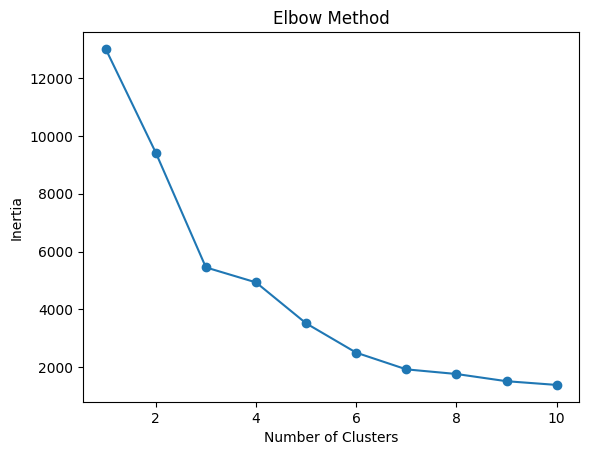

In [12]:
inertia = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Apply K-Means Clustering

In [13]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(rfm_scaled)

rfm['Cluster'] = clusters
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,182,4310.00,0
12348.0,75,31,1797.24,1
12349.0,19,73,1757.55,0
12350.0,310,17,334.40,3


# Evaluate Clustering

In [14]:
score = silhouette_score(rfm_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.3588023011776161


#  Cluster Analysis

In [15]:
cluster_summary = rfm.groupby('Cluster').mean()
print(cluster_summary)

            Recency    Frequency       Monetary
Cluster                                        
0         20.990788   135.285122    2645.818172
1         98.218703    37.719457     773.877083
2          4.692308  2565.307692  126118.310000
3        272.407005    25.138889     605.842525


# Visualize Clusters

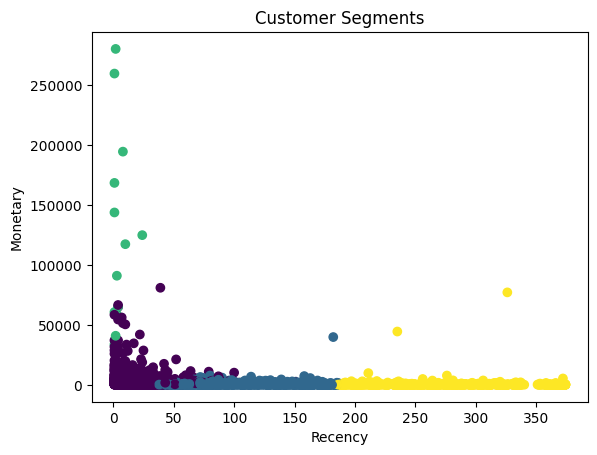

In [16]:
plt.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'])
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('Customer Segments')
plt.show()

• Clusters are clearly separated with visible boundaries.
• Customers within the same cluster show similar spending behavior.
• High-value customers form a compact and distinct group.
• Some overlap exists between medium-value customer groups.
• Works well for identifying structured and balanced customer segments.

Visualization Insight:
Scatter plots show round-shaped clusters because the algorithm groups customers based on distance from cluster centers.

# Other Unsupervised Algorithms

#  DBSCAN

In [17]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)
db_clusters = db.fit_predict(rfm_scaled)

rfm['DBSCAN_Cluster'] = db_clusters

In [18]:
print(rfm['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    4286
-1      46
 1       6
Name: count, dtype: int64


# visualize clusters

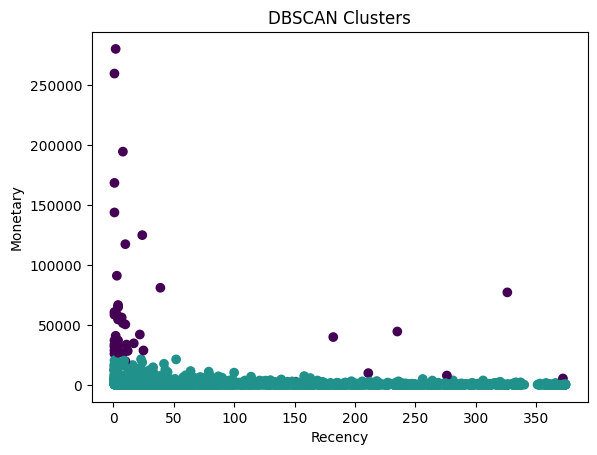

In [19]:
import matplotlib.pyplot as plt

plt.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['DBSCAN_Cluster'])
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('DBSCAN Clusters')
plt.show()

• Clusters are formed based on dense regions of customers.
• Noise points (outliers) are clearly identified.
• Irregular cluster shapes are visible.
• Some customers do not belong to any cluster due to low purchase activity.
• Suitable for detecting unusual customer behavior.

Visualization Insight:
Scatter plots show uneven cluster shapes and isolated points marked separately as noise.

# hierarchial clustring

In [20]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

# Dendrogram

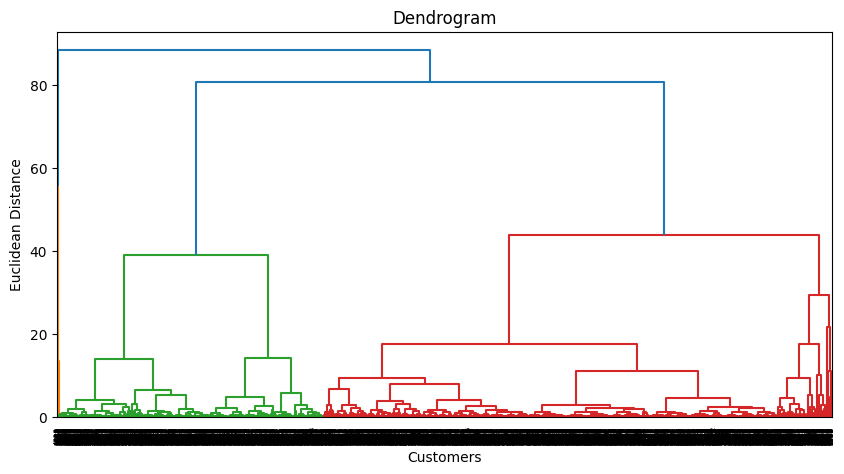

In [21]:
plt.figure(figsize=(10,5))
dendrogram = sch.dendrogram(sch.linkage(rfm_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()

# Apply Hierarchical Clustering

In [22]:
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
hc_clusters = hc.fit_predict(rfm_scaled)

# Add Cluster Labels

In [23]:
rfm['HC_Cluster'] = hc_clusters

In [24]:
print(rfm['HC_Cluster'].value_counts())

HC_Cluster
0    2843
2    1484
1       7
3       4
Name: count, dtype: int64


# visualize clusters 

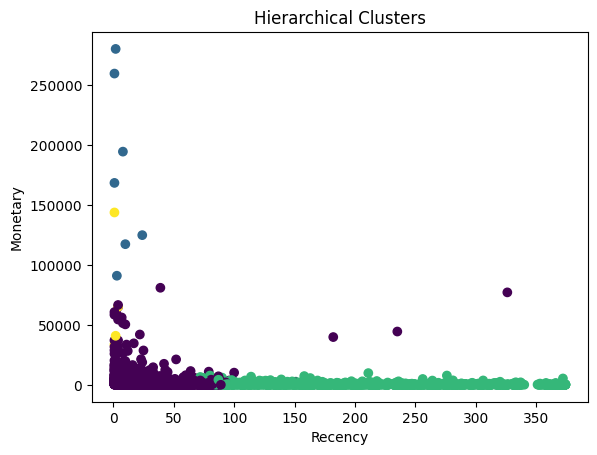

In [25]:
plt.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['HC_Cluster'])
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('Hierarchical Clusters')
plt.show()

• Customers are grouped step-by-step based on similarity.
• Dendrogram clearly shows how clusters are formed.
• Helps understand relationships between different customer groups.
• Cluster structure is more interpretable compared to other methods.
• Suitable for analyzing cluster hierarchy.

Visualization Insight:
Dendrogram diagram shows tree-like merging of customers into clusters at different similarity levels.

* K-Means → Best for clear and well-separated customer groups
* DBSCAN → Best for detecting outliers and irregular patterns
* Hierarchical → Best for understanding cluster relationships

In [26]:
import pickle

pickle.dump(kmeans, open("kmeans_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Pickle files saved!")

Pickle files saved!
